### Installation Section:
- make sure to install the `minigrid` package if needed.
- make sure to install the `imageio` package if needed.
- make sure to install the `gymnasium` package if needed.

In [11]:
# !pip install minigrid

### Imports Section
- make sure to import all the necessary libraries.
- make sure to install the packages if needed.

In [12]:
# Standard Libraries
import os, json, time, itertools, math
from collections import Counter, deque, defaultdict

# Scientific Computing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import cv2

# RL & Environments
import gymnasium as gym
import minigrid
from minigrid.wrappers import ImgObsWrapper, RGBImgPartialObsWrapper

# Torch & Models
import torch
import torch.nn as nn


# File handling and visuals
from pathlib import Path
import imageio
from typing import Optional, Tuple, Sequence

# Optional: smoothing and progress
from scipy.ndimage import uniform_filter1d
from tqdm import tqdm

# Set random seed
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

SEED = 42

In [13]:
# Automatically select device: MPS for macOS, CUDA for NVIDIA GPUs, or CPU as fallback
device = torch.device("mps" if torch.backends.mps.is_built() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


# === Final Evaluation Section ===


## === Instructions ===

📌 Instructions:
- Make sure our trained model best weights ("duel16_best_overall_0.82(full prioritized).pth" and "duel16_best_overall_0.84 (uniform)") are saved in the same folder as this notebook.
- This script runs 100 evaluation episodes per policy and plots rewards + steps.
- just run the cells below with the fllow to evaluate the trained policies.


## === Helper Functions and Classes for Dueling DRQN and A2C Agents ===

#### Helper Utility wrappers:

In [14]:
class SimpleResizeObs(gym.ObservationWrapper):
    """Resize ndarray observation (H,W,3) to target shape with nearest-neighbour.
    	•	Bigger receptive field – A 56×56 crop collapses after two 3×3 conv layers; 84×84 lets a small CNN capture spatial relations.
	    •	Video compatibility – 64, 80, 96, … are multiples of 16, so MP4 encoders don’t warn.
	    •	Consistent input – Every experiment, seed, and grid size produces the same tensor size for the network."""
    def __init__(self, env, shape=(84, 84)):
        super().__init__(env)
        self.shape = shape                # (H, W)
        h, w = shape
        # Detect whether we're dealing with a Dict or a Box
        if isinstance(env.observation_space, gym.spaces.Dict):
            c = env.observation_space["image"].shape[-1]
        else:                                    # already a Box
            c = env.observation_space.shape[-1]

        self.observation_space = gym.spaces.Box(
            low=0, high=255, shape=(h, w, c), dtype=np.uint8
        )

    def observation(self, obs: np.ndarray) -> np.ndarray:
        # Extract the RGB image
        if isinstance(obs, dict):
            img = obs["image"]
        else:
            img = obs                      # already a plain array

        # Resize (using cv2, PIL, or torch-vision – pick one)
        img = cv2.resize(img, self.shape, interpolation=cv2.INTER_AREA)
        return img


class SimpleFrameStack(gym.Wrapper):
    """Stack last *k* images along axis 0  →  (k,H,W,3) uint8.
    	•	Partial observability – the agent cannot see behind itself; stacked frames give a short-term memory of what just left view.
	    •	Motion cues – obstacle velocity (and the agent’s own motion) becomes visible via frame differences, letting a plain CNN learn without an LSTM.
	    •	Keeps network simple – avoids writing a custom recurrent head until we benchmark the basic CNN."""
    def __init__(self, env, k: int = 4):
        super().__init__(env)
        self.k        = k
        self.frames   = deque([], maxlen=k)
        h, w, c       = env.observation_space.shape
        self.observation_space = gym.spaces.Box(
            low = 0, high = 255, shape=(k, h, w, c), dtype=np.uint8
        )

    # ------------------------------------------------------------------ API
    def reset(self, **kw):
        obs, info = self.env.reset(**kw)
        self.frames.extend([obs] * self.k)          # fill deque
        return self._get_obs(), info

    def step(self, action):
        obs, r, term, trunc, info = self.env.step(action)
        self.frames.append(obs)
        return self._get_obs(), r, term, trunc, info
    # ----------------------------------------------------------------------
    def _get_obs(self):
        return np.stack(self.frames, axis=0)

#### Helper make_env function:

In [15]:
def make_env(size: str            = "16x16",
             seed: int            = 0,
             resize_to: Optional[Tuple[int, int]] = (64, 64),
             n_stack: int         = 1):
    """
    size      : '5x5', '6x6', '8x8', or '16x16'
    resize_to : None  → keep raw 56×56
                (H,W) → upscale with nearest‐neighbour
    n_stack   : 0 or 1 → no frame stack (DRQN)
                k>1     → stack last k frames (DQN)
    """
    env_id = f"MiniGrid-Dynamic-Obstacles-{size}-v0"
    env = gym.make(env_id, render_mode="rgb_array", highlight=False)

    # partial RGB crop → plain ndarray (H,W,3)
    env = RGBImgPartialObsWrapper(env)   # crop of what agent sees
    env = ImgObsWrapper(env)             # dict→ndarray (56,56,3)

    # optional up‐/down‐scaling
    if resize_to is not None:
        env = SimpleResizeObs(env, resize_to)      # e.g. (84,84,3)

    # only stack when you really want more than one frame
    if n_stack > 1:
        env = SimpleFrameStack(env, k=n_stack)     # e.g. (4,84,84,3)

    env.reset(seed=seed)
    return env

#### Dueling DRQN network Class:

In [16]:
class DuelingDRQN(nn.Module):
    """
    DRQN with a dueling head (value + advantage decomposition).

    Q(s,a) = V(s) + (A(s,a) - mean_a A(s,a))
    """
    def __init__(self,
                 obs_space : gym.spaces.Box,
                 n_actions : int,
                 hidden_dim: int = 512):
        super().__init__()

        # ── 1. input shape ────────────────────────────────────────
        shape = obs_space.shape
        if len(shape) == 3:         # (H, W, C)  – no stacking wrapper
            k, H, W = 1, shape[0], shape[1]
        else:                       # (k, H, W, C)  – MinigridFrameStack
            k, H, W = shape[0], shape[1], shape[2]
        in_ch = k * 3               # RGB frames

        # ── 2. convolutional encoder (unchanged) ──────────────────
        self.cnn = nn.Sequential(
            nn.Conv2d(in_ch, 32,  kernel_size=8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64,  kernel_size=4, stride=2), nn.ReLU(),
            nn.Conv2d(64, 64,  kernel_size=3, stride=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),   # (B, 64, 1, 1)
            nn.Flatten()                    # (B, 64)
        )

        # ── 3. GRU backbone ───────────────────────────────────────
        self.gru = nn.GRU(input_size=64,
                          hidden_size=hidden_dim,
                          batch_first=True)

        # ── 4. Dueling heads  ─────────────────────────────────────
        self.val_head = nn.Linear(hidden_dim, 1)        # V(s)
        self.adv_head = nn.Linear(hidden_dim, n_actions) # A(s,a)

    # -------------------------------------------------------------
    def forward(self, x, h=None):
        """
        x:  (B, T, H, W, C)  *or*  (B, H, W, C)
        h:  (1, B, hidden)  – optional GRU hidden state
        """
        # ensure time dimension
        if x.ndim == 4:
            x = x.unsqueeze(1)       # (B,1,H,W,C)

        B, T, H, W, C = x.shape
        x = x.view(B * T, H, W, C).permute(0, 3, 1, 2)   # to NCHW
        x = x.float() / 255.0 if x.dtype == torch.uint8 else x

        feat = self.cnn(x)                   # (B*T, 64)
        feat = feat.view(B, T, -1)           # (B, T, 64)

        gru_out, h = self.gru(feat, h)       # (B, T, hidden_dim)

        # dueling aggregation (vectorised over time)
        V = self.val_head(gru_out)           # (B, T, 1)
        A = self.adv_head(gru_out)           # (B, T, n_actions)
        Q = V + (A - A.mean(dim=-1, keepdim=True))

        return Q, h

## === Evaluation ===

#### Evaluation helper function to show the agent's view window (partial observation)

In [17]:
# ------------------------------------------------------------------
# Tiny helper: render full map and tint the agent’s 7×7 view
# ------------------------------------------------------------------
def render_with_view_tint(env, *, rgb=(0, 255, 0), alpha=0.25):
    """
    Returns an RGB frame where the agent’s current partial-obs window
    is lightly tinted (no split screen, no cv2 needed).
    """
    frame = env.render()                              # H×W×3 uint8
    H, W, _ = frame.shape
    gW, gH = env.unwrapped.width, env.unwrapped.height
    cell_w, cell_h = W / gW, H / gH

    topX, topY, botX, botY = env.unwrapped.get_view_exts()
    # --- NEW: ensure proper ordering -----------------------------
    if botX < topX: topX, botX = botX, topX
    if botY < topY: topY, botY = botY, topY
    # -------------------------------------------------------------

    # guarantee at least one grid-cell window
    if botX == topX: botX += 1
    if botY == topY: botY += 1

    # convert to pixel bounds
    x0 = int(np.floor(topX * cell_w))
    y0 = int(np.floor(topY * cell_h))
    x1 = int(np.ceil (botX * cell_w))
    y1 = int(np.ceil (botY * cell_h))

    # clip to frame
    x0, x1 = np.clip([x0, x1], 0, W)
    y0, y1 = np.clip([y0, y1], 0, H)


    # blend tint
    patch = frame[y0:y1, x0:x1].astype(np.float32)
    tint  = np.asarray(rgb, np.float32)
    blended = (1 - alpha) * patch + alpha * tint
    frame[y0:y1, x0:x1] = blended.astype(np.uint8)
    return frame

#### Evaluation function for the agent

In [18]:
# ─────────────────────────────────────────────────────
#   E V A L U A T E   N E U R A L   C H E C K P O I N T
# ─────────────────────────────────────────────────────
@torch.no_grad()
def evaluate_agent(
    ckpt_path : str,
    *,
    episodes   : int = 100,
    env_size   : str = "16x16",
    resize_to  : tuple[int,int] = (64,64),
    n_stack    : int = 1,
    tau        : float = 0.02,
    render     : bool  = False,
    record     : bool  = True,
    video_dir  : str   = ".",       # default folder where the notebook is saved
    tint_rgb   : tuple[int,int,int] = (0,255,0),
    tint_alpha : float = 0.25,
    seed_base  : int   = 10_000,
    device     = torch.device(device),
    model_builder = None        # optional factory; see note below
):
    """
    Evaluate a .pth checkpoint (A2C or Dueling-DRQN).

    • Saves up to 5 illustrative videos in <video_dir>.
    • Prints a mid-project-style textual summary.
    • Returns a dict with keys: rewards, steps, outcomes, success_rate, ci_95
    """

    # ── Load checkpoint ───────────────────────────────────
    # ckpt = torch.load(ckpt_path, map_location=device)
    ckpt = torch.load(
    ckpt_path,
    map_location=device,
    weights_only=False
)

    env = make_env(env_size, resize_to=resize_to, n_stack=n_stack, seed=seed_base)
    if render or record:
        env.unwrapped.render_mode = "rgb_array"
    n_actions = env.action_space.n

    # Choose network type -------------------------------------
    if model_builder is not None:
        net = model_builder(env.observation_space, n_actions).to(device)
    else:
        # default
        net = DuelingDRQN(env.observation_space, n_actions).to(device)

    net.load_state_dict(ckpt["model_state"], strict=True)
    net.eval()

    # ──  Evaluation loop ───────────────────────────────────
    rng   = np.random.default_rng()
    R, L, outcomes = [], [], []

    os.makedirs(video_dir, exist_ok=True)
    quota = dict(succ=2, coll=1, time=1)
    saved = dict.fromkeys(quota, 0)

    for ep in tqdm(range(episodes), desc="Evaluating"):
        obs, _ = env.reset(seed=seed_base + ep)
        done, h, ep_R = False, None, 0
        frames, rec_ok = [], record and any(saved[k] < quota[k] for k in quota)

        if rec_ok:
            frames.append(render_with_view_tint(env, rgb=tint_rgb, alpha=tint_alpha))

        while not done:
            if render:
                env.render()

            # --- inside the while-loop of evaluate_agent -------------------
            inp = torch.as_tensor(obs, device=device).unsqueeze(0).unsqueeze(
                    0 if obs.ndim == 3 else 1)

            out = net(inp, h)          # works for both DRQN and A2C
            if len(out) == 3:           # A2C ⇒ (logits, value, h)
                logits, _, h = out
                q = logits              # alias for downstream code
            else:                       # DRQN ⇒ (q_values, h)
                q, h = out
            # q now has shape (1, 1, A) regardless of model type
            q = q[0, -1]                # (A,)


            # τ-greedy tie-aware action
            best = int(q.argmax())
            if tau > 0 and (q.max() - q.topk(2).values[1]) < tau:
                ties = (q >= q.max() - 1e-6).nonzero(as_tuple=True)[0]
                best = int(ties[rng.integers(len(ties))])

            obs, r, term, trunc, _ = env.step(best)
            done  = term or trunc
            ep_R += r

            if rec_ok:
                frames.append(render_with_view_tint(env, rgb=tint_rgb, alpha=tint_alpha))

            # cut gradient history
            if isinstance(h, tuple):
                h = (h[0].detach(), h[1].detach())
            elif h is not None:
                h = h.detach()

        outcome = ("succ" if term and r > 0 else
                   "coll" if term and r < 0 else
                   "time")

        if rec_ok and saved[outcome] < quota[outcome]:
            fname = f"{video_dir}/{Path(ckpt_path).stem}_{outcome}_ep{ep:02d}.mp4"
            imageio.mimsave(fname, frames[::2] if len(frames) > 250 else frames, fps=15)
            saved[outcome] += 1
            print(f"📹  saved → {fname}")

        R.append(ep_R)
        L.append(env.unwrapped.step_count)
        outcomes.append(outcome)

    env.close()

    #  Text summary ---------------------------------------------------
    counts  = Counter(outcomes)
    sr      = counts["succ"] / episodes
    ci95    = 1.96 * math.sqrt(sr * (1 - sr) / episodes)

    print(f"\n✅  Evaluation over {episodes} episodes | τ={tau}")
    print(f"   Success {sr:.3f} ±{ci95:.3f}   "
          f"Collision {counts['coll']/episodes:.3f}   "
          f"Timeout {counts['time']/episodes:.3f}")
    print(f"   Avg Reward {np.mean(R):+6.3f}   Avg Steps {np.mean(L):.1f}\n")

    return dict(
        rewards      = np.asarray(R),
        steps        = np.asarray(L),
        outcomes     = outcomes,
        success_rate = sr,
        ci_95        = ci95
    )

### Plotting helper for evaluation results

In [19]:
# My new version of `plot_eval_results()` that includes all metrics
def plot_eval_results(eval_results, *, label="Agent 16×16"):
    """
    Visualises all evaluation metrics returned by `evaluate_policy()`.

    Expected keys in `eval_results`
    --------------------------------
    rewards         : list[float]    – per-episode total (un-shaped) reward
    steps           : list[int]      – episode length (steps)
    outcomes        : list[str]      – 'succ' | 'coll' | 'time'
    success_rate    : float          – mean success fraction
    ci_95           : float | None   – half-width of 95 % CI (optional)
    """

    # ---------- unpack & basic stats ---------------------------------------
    rewards = np.asarray(eval_results["rewards"])
    steps   = np.asarray(eval_results["steps"])
    outcomes = eval_results["outcomes"]
    sr   = eval_results["success_rate"]
    ci95 = eval_results.get("ci_95")          # might be absent

    counts = Counter(outcomes)                # succ / coll / time
    N      = len(rewards)

    # ---------- create 2×2 figure ------------------------------------------
    fig, ax = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(
        f"{label} – evaluation over {N} episodes\n"
        f"Success = {sr:.3f}" + (f" ± {ci95:.3f}" if ci95 is not None else ""),
        fontsize=14, y=1.03
    )

    # reward distribution --------------------------------------------------
    ax[0, 0].hist(rewards, bins=20, alpha=0.75, color="#4c72b0")
    ax[0, 0].axvline(rewards.mean(), color="r", linestyle="--",
                     label=f"Mean {rewards.mean():+.2f}")
    ax[0, 0].set(title="Reward distribution",
                 xlabel="Total reward",
                 ylabel="Freq")
    ax[0, 0].legend()

    # steps distribution ---------------------------------------------------
    ax[0, 1].hist(steps, bins=20, alpha=0.75, color="#55a868")
    ax[0, 1].axvline(steps.mean(), color="r", linestyle="--",
                     label=f"Mean {steps.mean():.1f}")
    ax[0, 1].set(title="Episode lengths",
                 xlabel="Steps",
                 ylabel="Freq")
    ax[0, 1].legend()

    # outcome bar chart ----------------------------------------------------
    ax[1, 0].bar(["Success", "Collision", "Timeout"],
                 [counts["succ"], counts["coll"], counts["time"]],
                 color=["#4c72b0", "#c44e52", "#8172b3"])
    ax[1, 0].set(title="Outcome distribution",
                 ylabel="Count")

    # reward vs. steps scatter (efficiency) -------------------------------
    ax[1, 1].scatter(steps, rewards, alpha=0.7, s=18)
    ax[1, 1].set(title="Reward vs. steps",
                 xlabel="Steps",
                 ylabel="Reward")
    ax[1, 1].grid(True, linestyle=":")

    plt.tight_layout()
    plt.show()

### Helper to run and report results for our model

In [20]:
# ------------------------------------------------------------
# Convenience wrapper: evaluate -> print -> plot
# ------------------------------------------------------------
def run_and_report_dl(
    ckpt_path : str,
    *,
    label      = "Agent 16×16",
    episodes   = 100,
    tau        = 0.02,
    render     = False,
    **kwargs                       # passed straight to evaluate_agent
):
    metrics = evaluate_agent(
        ckpt_path,
        episodes = episodes,
        tau      = tau,
        render   = render,
        **kwargs
    )
    plot_eval_results(metrics, label=label)
    return metrics

## === Run evaluations instructions ===
Before running the evaluation, make sure the checkpoint filenames below match the correct trained models:
1. "duel16_best_overall_0.82(full prioritized).pth"
2. "duel16_best_overall_0.84 (uniform).pth"

- Set the value of tau (τ) to control evaluation behavior:
    - tau = 0.0 → strict greedy policy (deterministic actions)
    - tau = 0.02 → soft-greedy (Boltzmann-style sampling to break near-ties)
- After each run:
    - A full text summary will be printed with:
        - Success, collision, and timeout rates
        - Confidence interval (CI) for success
        - Average episode return and length
    - Up to 4 illustrative videos will be automatically saved:
        - 2 random success episodes
        - 1 random collision (if one occurred)
        - 1 random timeout (if one occurred)
        - Videos are saved as defualt in the same folder as this notebook (or in the folder you specify with video_dir)

#### DuellingDRQN evaluation - with prioritized replay buffer
- our best model

Evaluating:   1%|          | 1/100 [00:00<00:39,  2.49it/s]

📹  saved → ./duel16_best_overall_0.82(full prioritized)_succ_ep00.mp4


Evaluating:   2%|▏         | 2/100 [00:00<00:28,  3.49it/s]

📹  saved → ./duel16_best_overall_0.82(full prioritized)_succ_ep01.mp4


Evaluating:  22%|██▏       | 22/100 [00:06<00:28,  2.71it/s]

📹  saved → ./duel16_best_overall_0.82(full prioritized)_coll_ep20.mp4


Evaluating: 100%|██████████| 100/100 [00:33<00:00,  2.98it/s]



✅  Evaluation over 100 episodes | τ=0.02
   Success 0.980 ±0.027   Collision 0.020   Timeout 0.000
   Avg Reward +0.902   Avg Steps 67.4



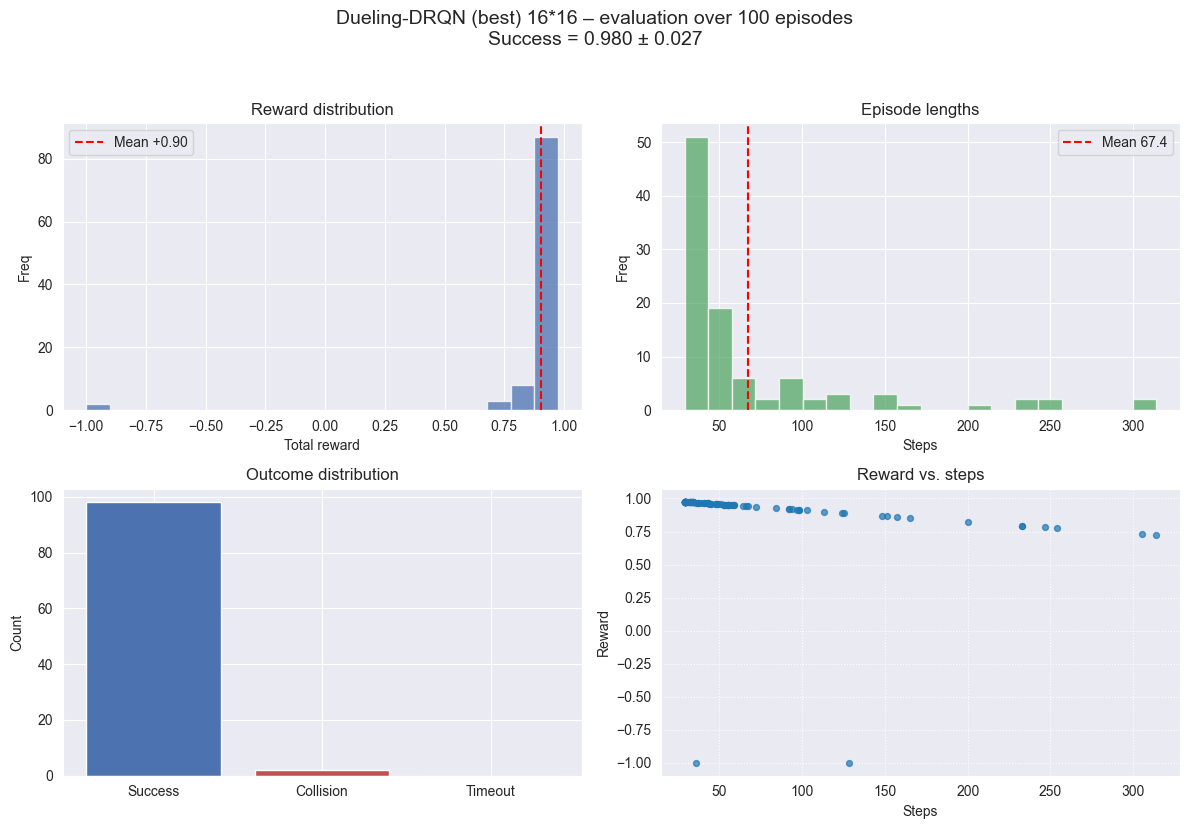

In [21]:
# Evaluate DuellingDRQN model
duel_drqn_best_metrics = run_and_report_dl(
    "duel16_best_overall_0.82(full prioritized).pth",
    label = "Dueling-DRQN (best) 16*16",
    episodes = 100,
    record   = True,               # True is you want to save illustrative MP4s
    tau = 0.02             # soft-greedy - can be 0.0 for strict greedy
)

#### DuellingDRQN evaluation - with uniform replay buffer
- our best second model

Evaluating:   1%|          | 1/100 [00:02<04:36,  2.79s/it]

📹  saved → ./duel16_best_overall_0.84 (uniform)_succ_ep00.mp4


Evaluating:   2%|▏         | 2/100 [00:03<02:07,  1.30s/it]

📹  saved → ./duel16_best_overall_0.84 (uniform)_succ_ep01.mp4


Evaluating: 100%|██████████| 100/100 [00:59<00:00,  1.69it/s]


✅  Evaluation over 100 episodes | τ=0.02
   Success 1.000 ±0.000   Collision 0.000   Timeout 0.000
   Avg Reward +0.891   Avg Steps 124.5



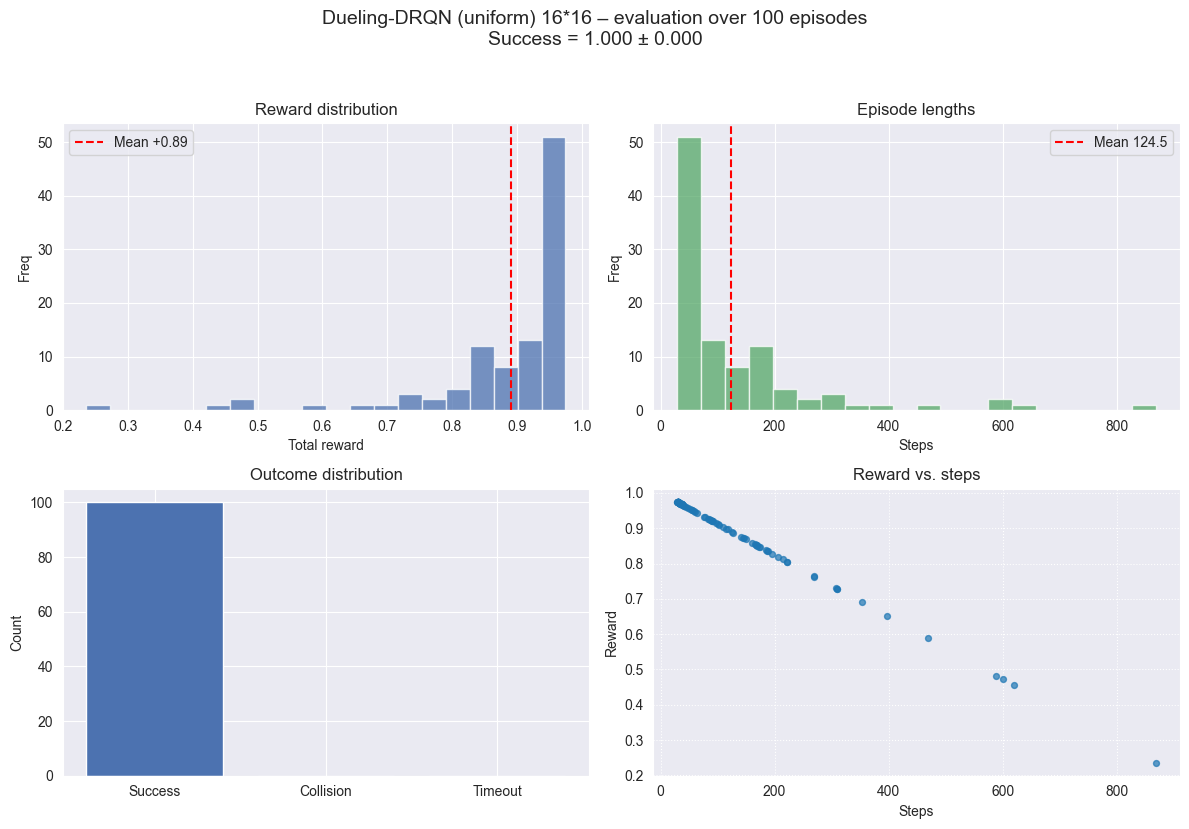

In [22]:
# Evaluate DuellingDRQN model
duel_drqn_uniform_metrics = run_and_report_dl(
    "duel16_best_overall_0.84 (uniform).pth",
    label = "Dueling-DRQN (uniform) 16*16",
    episodes = 100,
    record   = True,               # True is you want to save illustrative MP4s
    tau = 0.02             # soft-greedy - can be 0.0 for strict greedy
)

#### Summary Table of the evaluation results of both policies (DuellingDRQN best and DuellingDRQN uniform - without prioritized replay buffer)

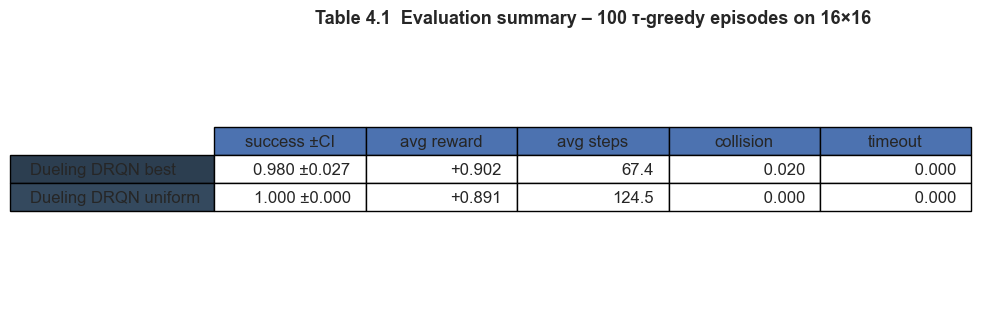

In [23]:
def _summary_row(metrics: dict) -> list:
    """Return a list of strings for the comparison table."""
    counts = Counter(metrics["outcomes"])
    n      = len(metrics["rewards"])
    return [
        f"{metrics['success_rate']:.3f} ±{metrics['ci_95']:.3f}",  # success ±CI
        f"{np.mean(metrics['rewards']):+6.3f}",                    # avg reward
        f"{np.mean(metrics['steps']):4.1f}",                       # avg steps
        f"{counts['coll']/n: .3f}",                                # collision
        f"{counts['time']/n: .3f}",                                # timeout
    ]

columns = ["success ±CI", "avg reward", "avg steps", "collision", "timeout"]
data    = {
    "Dueling DRQN best": _summary_row(duel_drqn_best_metrics),
    "Dueling DRQN uniform"        : _summary_row(duel_drqn_uniform_metrics)
}

df = pd.DataFrame(data, index=columns).T

# ---- render as a MPL table so it’s captured in the PDF ----------
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.axis("off")
tbl = ax.table(
    cellText   = df.values,
    colLabels  = df.columns,
    rowLabels  = df.index,
    colColours = ["#4c72b0"]*len(columns),
    rowColours = ["#2c3e50", "#34495e"],
    loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1.1, 1.6)

plt.title("Table 4.1  Evaluation summary – 100 τ-greedy episodes on 16×16",
          pad=12, fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

#### Plotting the CDF of episode lengths for both policies
- this is useful to see the tail-risk of the policies
- we can see that the duelling DRQN with uniform replay buffer has a longer tail-risk


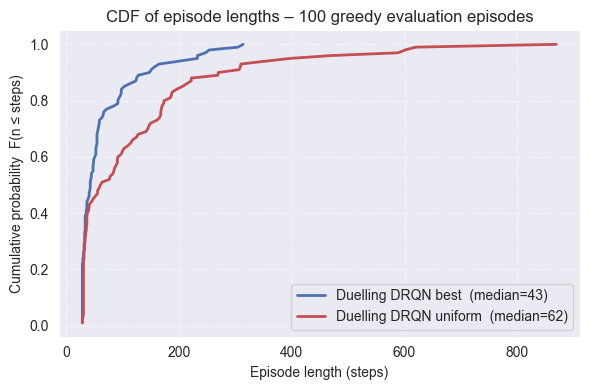

In [24]:
# ------------------------------------------------------------
# Figure X – CDF of episode lengths (tail-risk)
# ------------------------------------------------------------
def plot_episode_length_cdf(metrics_list, labels, *, colors=None):
    """
    Plot the empirical CDF of episode lengths for one or more agents.

    Parameters
    ----------
    metrics_list : list[dict]
        Each dict is the output of `evaluate_policy()`, containing "steps".
    labels       : list[str]
        Legend labels for the curves (same order as metrics_list).
    colors       : list[str] | None
        Optional list of matplotlib-compatible colors.
    """
    if colors is None:
        colors = ["#4c72b0", "#c44e52", "#55a868", "#8172b3"]

    plt.figure(figsize=(6, 4))

    for idx, (m, lbl) in enumerate(zip(metrics_list, labels)):
        steps  = np.asarray(m["steps"])
        sorted_steps = np.sort(steps)
        cdf    = np.linspace(1/len(steps), 1.0, len(steps))  # F(n) = n/N
        plt.plot(sorted_steps,
                 cdf,
                 lw=2,
                 label=f"{lbl}  (median={np.median(steps):.0f})",
                 color=colors[idx % len(colors)])

    plt.xlabel("Episode length (steps)")
    plt.ylabel("Cumulative probability  F(n ≤ steps)")
    plt.title("CDF of episode lengths – 100 greedy evaluation episodes")
    plt.grid(True, linestyle=":")
    plt.legend()
    plt.tight_layout()
    plt.show()

# -----------------------------------------------------------------
# usage of function
# -----------------------------------------------------------------
plot_episode_length_cdf(
    metrics_list=[duel_drqn_best_metrics, duel_drqn_uniform_metrics],
    labels      =["Duelling DRQN best", "Duelling DRQN uniform"]
)